# Probability -- Coin Flips and Experiments

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set(color_codes = True)
sns.set_style("white")

In [2]:
np.random.uniform(low=0.0, high=1.0)

0.6608507685634742

In [3]:
# Generate a 'flip'
def flip(freq = 1):
    flips = []

    for i in range(freq):
        num = np.random.uniform(low=0.0, high=1.0)
        if num > 0.5:
            flips.append("H")
        else:
            flips.append("T")
    return flips

In [4]:
flip()

['T']

In [5]:
num_flips = flip(10)
print(num_flips)

['T', 'T', 'T', 'T', 'H', 'H', 'T', 'H', 'T', 'H']


In [6]:
values, counts = np.unique(num_flips, return_counts=True)

In [7]:
print(f"Values: {values}\nCounts: {counts}")

Values: ['H' 'T']
Counts: [4 6]


# Reproducible 'Randomness'

In [8]:
# computers are 'deterministic'. You can not do 'random' in computers! 
# So, you start with some 'seed' then do deterministic things 
# this is called pseudo-randomness 

# sometimes you want to suppress this! 

np.random.seed(0)   # random numbers and seed 

In [9]:
np.random.uniform(low=0.0, high=1.0)

0.5488135039273248

In [10]:
np.random.seed(0)

# Generate a 'flip'
def flip(freq = 1):
    flips = []

    for i in range(freq):
        num = np.random.uniform(low=0.0, high=1.0)
        if num > 0.5:
            flips.append("H")
        else:
            flips.append("T")
    return flips


num_flips = flip(10)
values, counts = np.unique(num_flips, return_counts=True)

print(num_flips)
print(f"Values: {values}\nCounts: {counts}")

['H', 'H', 'H', 'H', 'T', 'H', 'T', 'H', 'H', 'T']
Values: ['H' 'T']
Counts: [7 3]


# Probability Of Flips

In [11]:
# num_flips = ['T'] # to check the defaultdict behavior

In [12]:
from collections import Counter, defaultdict 

def get_freq(num_flips):
    keys = Counter(num_flips).keys()
    freq = Counter(num_flips).values()

    # return dict(zip(keys, freq)) # bug: what if there are no 'H' or no 'T'

    return defaultdict(int, dict(zip(keys, freq)))

In [13]:
frequency = get_freq(num_flips)
print(frequency)

defaultdict(<class 'int'>, {'H': 7, 'T': 3})


In [14]:
prob_head = frequency['H'] / len(num_flips)
print(prob_head)

0.7


In [15]:
prob_tail = frequency['T'] / len(num_flips)
print(prob_tail)

0.3


# Experiment

## Probability calculated based on 1 flip upto N flips

In [19]:
max_flips = 1000

prob = []
for num_flips in range(1, max_flips):
    flips = flip(num_flips)
    freq = get_freq(flips)
    prob_h = freq['H']/len(flips)

    prob.append(prob_h)

In [20]:
print(freq)

defaultdict(<class 'int'>, {'H': 530, 'T': 469})


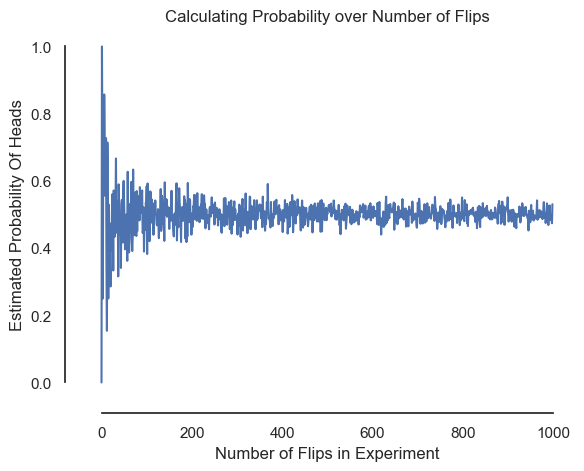

In [24]:
plt.plot(prob)
plt.ylabel("Estimated Probability Of Heads")
plt.xlabel("Number of Flips in Experiment")
plt.title("Calculating Probability over Number of Flips")
sns.despine(offset=10, trim=True)
plt.show()

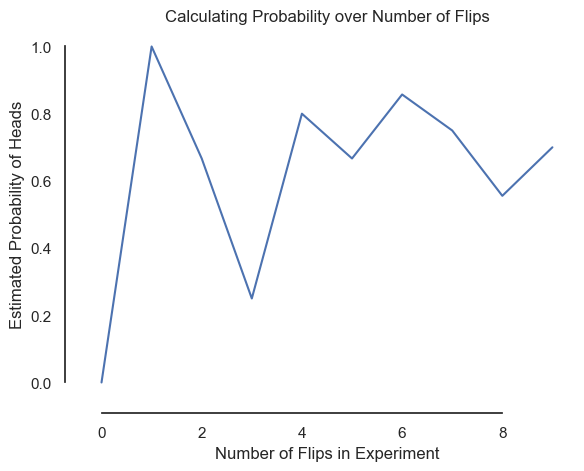

In [25]:
plt.plot(prob[:10])
plt.ylabel("Estimated Probability of Heads")
plt.xlabel("Number of Flips in Experiment")
plt.title("Calculating Probability over Number of Flips")
sns.despine(offset=10, trim=True)
plt.show()

In [ ]:
plt.plot(prob)
plt.ylabel("Estimated Probability")
plt.xlabel("Number of Flips in Experiment")
plt.title("Calculating Probability over Number of Flips")
sns.despine(offset=10, trim=True)
plt.show()